### PASO 1 y 2: Carga de Datos y Arquitectura del Modelo
Configuramos el dataset Iris y definimos una red neuronal simple.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

# 1. Preparación de datos
iris = load_iris()
X = StandardScaler().fit_transform(iris.data)
y = iris.target

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

# 2. Definición de la Red Neuronal
class IrisClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4, 8)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(8, 3)

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

### PASO 3: Configuración de Muestreo Estratificado
Implementamos la lógica para garantizar 1 muestra de cada clase por batch.

In [2]:
def get_stratified_batches(X, y, samples_per_class=1):
    idx_0 = np.where(y.numpy() == 0)[0]
    idx_1 = np.where(y.numpy() == 1)[0]
    idx_2 = np.where(y.numpy() == 2)[0]

    np.random.shuffle(idx_0)
    np.random.shuffle(idx_1)
    np.random.shuffle(idx_2)

    num_batches = min(len(idx_0), len(idx_1), len(idx_2)) // samples_per_class

    batches = []
    for i in range(num_batches):
        batch_idx = np.concatenate([
            idx_0[i*samples_per_class : (i+1)*samples_per_class],
            idx_1[i*samples_per_class : (i+1)*samples_per_class],
            idx_2[i*samples_per_class : (i+1)*samples_per_class]
        ])
        np.random.shuffle(batch_idx)
        batches.append((X[batch_idx], y[batch_idx]))
    return batches

### PASO 4: Bucle de Entrenamiento y Comparación

In [3]:
epochs = 60
lr = 0.05

def train_model(stratified=False):
    torch.manual_seed(42)
    np.random.seed(42)
    model = IrisClassifier()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    epoch_losses = []
    grad_stds = []

    for epoch in range(epochs):
        if stratified:
            batches = get_stratified_batches(X_tensor, y_tensor, samples_per_class=1)
        else:
            dataset = TensorDataset(X_tensor, y_tensor)
            loader = DataLoader(dataset, batch_size=3, shuffle=True)
            batches = [(bx, by) for bx, by in loader]

        epoch_loss = 0.0
        batch_grads = []

        for bx, by in batches:
            optimizer.zero_grad()
            out = model(bx)
            loss = criterion(out, by)
            loss.backward()

            # Capturamos la norma del gradiente para medir el ruido
            grad_norm = nn.utils.clip_grad_norm_(model.parameters(), max_norm=100)
            batch_grads.append(grad_norm.item())

            optimizer.step()
            epoch_loss += loss.item()

        epoch_losses.append(epoch_loss / len(batches))
        grad_stds.append(np.std(batch_grads))

    return epoch_losses, grad_stds

loss_rand, grad_rand = train_model(stratified=False)
loss_strat, grad_strat = train_model(stratified=True)

### PASO 5: Visualización de Resultados

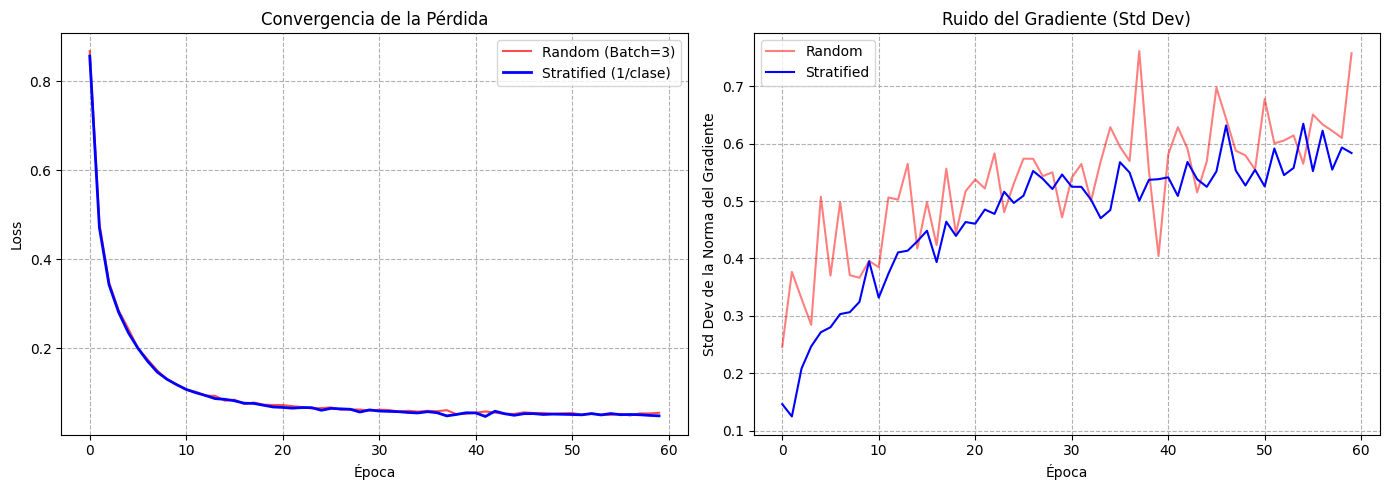

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(loss_rand, label='Random (Batch=3)', color='red', alpha=0.7)
ax1.plot(loss_strat, label='Stratified (1/clase)', color='blue', linewidth=2)
ax1.set_title('Convergencia de la Pérdida')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--')

ax2.plot(grad_rand, label='Random', color='red', alpha=0.5)
ax2.plot(grad_strat, label='Stratified', color='blue', linewidth=1.5)
ax2.set_title('Ruido del Gradiente (Std Dev)')
ax2.set_xlabel('Época')
ax2.set_ylabel('Std Dev de la Norma del Gradiente')
ax2.legend()
ax2.grid(True, linestyle='--')

plt.tight_layout()
plt.show()